# Tiny NeRF (Tutorial 10.4 baseline)
**Group 4**: Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

The Tutorial 10.4 Tiny NeRF, used as the baseline for Project 8. The model and renderer are the tutorial's; the only changes are those needed for a fair, reproducible evaluation: a fixed seed, the shared training budget and learning-rate decay, a faster (but content-identical) batch loader, chunked rendering of test images, and saving the trained weights for `main_report.ipynb`.

In [1]:
# PyTorch NeRF Implementation (same stack as Tutorial 10.4)
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output

# Set device. Every tensor and network below is moved to it with .to(device).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | torch {torch.__version__}")

# Reproducibility: one seed for weights, ray shuffling and the stratified jitter.
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Scene bounds and sample budgets shared by every model in this project.
NEAR, FAR = 2.0, 6.0          # ray segment that contains the object (tutorial values)
N_SAMPLES_TINY = 64           # Tiny NeRF: uniform samples per ray (tutorial value)
N_C, N_F = 32, 64             # Extended NeRF: coarse samples, extra fine samples (starter values)

Using device: cuda | torch 2.13.0+cu126


# Data - Batching Rays
The synthetic scene `tiny_nerf_data.npz` holds 106 posed 100x100 RGB images of a Lego
bulldozer and the camera's focal length. Each pose is a 4x4 camera-to-world matrix: its first
three columns turn camera axes into world axes and its last column is the camera centre. As in
the starter code, views 0-99 train the model and views 100-105 are held out for testing, so every
reported metric comes from cameras the model never saw.

In [2]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float().to(device)
poses = torch.from_numpy(data['poses']).float().to(device)
focal = float(data['focal'])
H, W = images.shape[1:3]
K = torch.Tensor([[focal, 0, W/2.0], [0, focal, H/2.0], [0, 0, 1]]).float().to(device)
print(f"dataset: Images shape={images.shape}, Poses shape={poses.shape}, Intrinsics={K.shape}")

# Splitting the dataset into training and test sets exactly as the starter code does:
# the last 6 views are never seen during training and are used for every reported metric.
test_images, test_poses = images[100:], poses[100:]
train_images, train_poses = images[:100], poses[:100]
print(f"training split: {train_images.shape}, training pose shape: {train_poses.shape}")
print(f"test split: {test_images.shape}, test pose shape: {test_poses.shape}")

dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4]), Intrinsics=torch.Size([3, 3])
training split: torch.Size([100, 100, 100, 3]), training pose shape: torch.Size([100, 4, 4])
test split: torch.Size([6, 100, 100, 3]), test pose shape: torch.Size([6, 4, 4])


The six training views on top and the six held-out test views underneath, to show what the model
has to reproduce: the cameras circle the object at different heights.

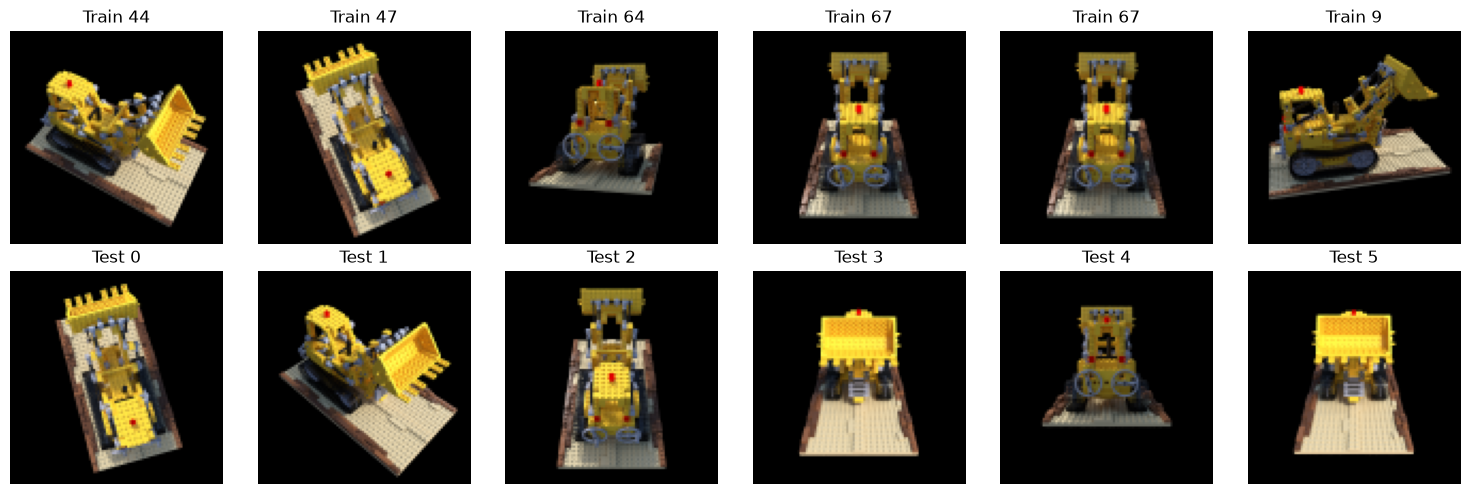

In [3]:
# Six training views (top) and the six held-out test views (bottom).
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, sample_idx in enumerate(np.random.randint(0, train_images.shape[0], 6)):
    axes[0, i].imshow(train_images[sample_idx].cpu().numpy())
    axes[0, i].set_title(f'Train {sample_idx}')
    axes[0, i].axis('off')
for i in range(6):
    axes[1, i].imshow(test_images[i].cpu().numpy())
    axes[1, i].set_title(f'Test {i}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Each pixel defines a ray $\mathbf{r}(t) = \mathbf{o} + t\mathbf{d}$ from the camera centre
$\mathbf{o}$ through the pixel. `get_rays` builds the direction in camera coordinates from the
pinhole model, $((i - c_x)/f,\; -(j - c_y)/f,\; -1)$ (the camera looks down its own $-z$ axis
and image rows grow downwards), then rotates it into world coordinates with the pose.

In [4]:
def get_rays(K, c2w, H, W):
    """
    Get the origin and direction of the ray through every pixel of a camera with
    intrinsics K and camera-to-world pose c2w (Tutorial 10.4, unchanged).
    """
    # 1. Create pixel grid, x first
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )

    # 2. Get directions in camera coordinates: (u - cx)/fx, (v - cy)/fy, with the camera
    #    looking down -z and the y-axis flipped (standard NeRF orientation)
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1],
        -torch.ones_like(i)
    ], dim=-1)

    # 3. Transform directions to world space: (H, W, 3) @ (3, 3) -> (H, W, 3)
    rays_d = dirs @ c2w[:3, :3].T

    # 4. Origin is the translation vector of the camera-to-world matrix
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

All 100 x 100 x 100 = 1,000,000 training rays are pooled and served in shuffled batches of 1,024,
so one gradient step mixes pixels from many cameras rather than one image at a time.

In [5]:
class NeRFDataset(torch.utils.data.Dataset):
    """Pool of all training rays (Tutorial 10.4, unchanged)."""
    def __init__(self, images, poses, intrinsic):
        """
        images: (N_images, H, W, 3)
        poses: (N_images, 4, 4)
        """
        self.images, self.poses, self.intrinsic = images, poses, intrinsic
        self.H, self.W = images.shape[1], images.shape[2]
        self.all_rays_o, self.all_rays_d, self.all_rays_rgbs = [], [], []

        # compute all rays
        for i in range(len(images)):
            rays_o, rays_d = get_rays(self.intrinsic, self.poses[i], self.H, self.W)
            self.all_rays_o.append(rays_o.reshape(-1, 3))
            self.all_rays_d.append(rays_d.reshape(-1, 3))
            self.all_rays_rgbs.append(images[i].reshape(-1, 3))

        # Concatenate all rays from all images
        self.all_rays_o = torch.cat(self.all_rays_o, dim=0)
        self.all_rays_d = torch.cat(self.all_rays_d, dim=0)
        self.all_rays_rgbs = torch.cat(self.all_rays_rgbs, dim=0)

    def __len__(self):
        return len(self.all_rays_o)

    def __getitem__(self, idx):
        return (self.all_rays_o[idx], self.all_rays_d[idx], self.all_rays_rgbs[idx])


def make_train_dataloader(seed=SEED, batch_size=1024):
    """
    Same dataset, batch size (1024 rays) and shuffling as the tutorial. The only change is
    how a batch is fetched: a BatchSampler hands __getitem__ a whole list of indices, so a
    batch is one tensor gather on the GPU instead of 1,024 Python calls plus a collate. The
    batches are identical in content; an epoch simply runs several times faster.
    """
    dataset = NeRFDataset(train_images, train_poses, K)
    generator = torch.Generator().manual_seed(seed)
    batch_sampler = torch.utils.data.BatchSampler(
        torch.utils.data.RandomSampler(dataset, generator=generator), batch_size, drop_last=False)
    return torch.utils.data.DataLoader(dataset, sampler=batch_sampler, batch_size=None)

# Model - Neural Scene Representation
**Positional encoding.** A small MLP fed raw coordinates learns only smooth functions, so sharp
edges and fine texture come out blurred. Lifting each coordinate to
$\gamma(p) = (p, \sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p))$
gives the network inputs that already vary quickly, so detail costs it far less. With $L = 6$ a 3D
point becomes $3 + 3 \cdot 2 \cdot 6 = 39$ numbers.

In [6]:
class PositionalEncoding(torch.nn.Module):
    """
    Positional encoding gamma(p) = [p, sin(2^k pi p), cos(2^k pi p)], k = 0..L-1 (Tutorial 10.4).
    Maps (N, D) -> (N, D + 2*L*D).
    """
    def __init__(self, L_embed=6):
        super(PositionalEncoding, self).__init__()
        self.L_embed = L_embed
        self.bands = (2.0 ** torch.arange(L_embed, dtype=torch.float32).to(device)) * torch.pi
        self.bands = self.bands.view(1, L_embed, 1)  # shape (1, L_embed, 1)

    def forward(self, x):
        x_scaled = x.unsqueeze(-2) * self.bands                                  # (N, L, D)
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2)  # (N, 2L, D)
        sin_cos = sin_cos.flatten(start_dim=-2)                                  # (N, 2LD)
        return torch.cat([x, sin_cos], dim=-1)                                   # (N, D + 2LD)

The Tiny NeRF MLP has **no view dependence**: colour is a function of position only, so every 3D
point has one colour whichever camera looks at it (a matte renderer). Three layers map the 39
encoded numbers to 128, 128 and finally 4 outputs: density $\sigma$ (kept non-negative by a
ReLU) and colour (kept in $[0, 1]$ by a sigmoid).

In [7]:
class TinyNeRF(torch.nn.Module):
    """
    The Tutorial 10.4 model, unchanged apart from its name: a 3-layer MLP that maps the encoded
    position gamma(x) to (sigma, rgb). It never sees the viewing direction, so it is a matte
    renderer: every 3D point has one colour whichever camera looks at it.
    """
    def __init__(self, filter_size=128, L_embed=6):
        super(TinyNeRF, self).__init__()
        self.positional_encoding = PositionalEncoding(L_embed)
        self.layer1 = torch.nn.Linear(3 + 3*2*L_embed, filter_size)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)
        self.layer3 = torch.nn.Linear(filter_size, 4)
        self.relu = torch.nn.functional.relu

    def forward(self, x):
        x = self.positional_encoding(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        sigma = self.relu(x[..., [0]])     # density >= 0
        rgb = torch.sigmoid(x[..., 1:])    # colour in [0, 1]
        return torch.cat([sigma, rgb], dim=-1)

# Inference - Volume Rendering
A pixel's colour is the colour of the ray's samples, each weighted by how much light it sends to
the camera:
$C(\mathbf{r}) \approx \sum_i w_i \mathbf{c}_i$ with $w_i = T_i\alpha_i$,
$\alpha_i = 1 - e^{-\sigma_i\delta_i}$ (the chance the ray stops in sample $i$'s interval of
length $\delta_i$) and $T_i = \prod_{j<i}(1-\alpha_j)$ (the chance it got that far). The weights
$w_i$ therefore show where along the ray the visible surface is, which Task 2 uses.

In [8]:
def volume_rendering(sigma, rgb, t_vals):
    """
    Discrete volume rendering (Tutorial 10.4, unchanged).
    sigma: [N_rays, N_samples], rgb: [N_rays, N_samples, 3], t_vals: [N_rays, N_samples].
    Returns the pixel colours [N_rays, 3] and the per-sample weights w_i = T_i * alpha_i.
    """
    # Distance between adjacent samples, with a very large last interval
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    last_dist = torch.full_like(deltas[..., :1], 1e10)
    deltas = torch.cat([deltas, last_dist], dim=-1)

    # alpha_i = 1 - exp(-sigma_i * delta_i)  (sigma >= 0 is ensured by the ReLU in the MLP)
    alpha = 1.0 - torch.exp(-sigma * deltas)

    # Transmittance T_i = prod_{j<i} (1 - alpha_j), with T_1 = 1
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]

    # colour blending
    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    return rgb_map, weights

Tiny NeRF places `N_SAMPLES_TINY = 64` samples evenly between `near = 2` and `far = 6` on every ray.
During training each sample is jittered inside its bin, so over many steps the network sees every
depth, not only 64 fixed ones.

In [9]:
def render_rays_tiny(network, rays_o, rays_d, near, far, num_samples, rand=False):
    """Tutorial 10.4 renderer: uniform (stratified when rand=True) samples, one network."""
    # 1. Generate t_vals for each ray: [N_rays, num_samples]
    z_vals = torch.linspace(near, far, num_samples, device=rays_o.device)
    z_vals = z_vals.expand(list(rays_o.shape[:-1]) + [num_samples])
    if rand:
        # 1.1 Add jitter: one uniform sample inside each of the num_samples bins
        bin_edges = torch.linspace(near, far, num_samples + 1, device=rays_o.device)
        lower = bin_edges[:-1]; widths = bin_edges[1:] - lower
        z_vals = lower + torch.rand_like(z_vals) * widths

    # 2. Points in space: r(t) = o + td
    pts = rays_o[..., None, :] + z_vals[..., :, None] * rays_d[..., None, :]

    # 3. network pass to compute density and colour
    raw = network(pts.view(-1, 3)).view(list(pts.shape[:-1]) + [4])   # [N_rays, N_samples, 4]
    sigma, rgb = raw[..., 0], raw[..., 1:]

    # 4. Volume rendering
    rgb_map, weights = volume_rendering(sigma, rgb, z_vals)
    return rgb_map

## Evaluation helpers
**PSNR** is $-10\log_{10}(\mathrm{MSE})$ for images in $[0, 1]$ (the tutorial's metric): every
halving of the squared error adds about 3 dB. **SSIM** (Wang et al., 2004) compares local means,
contrast and structure in 11 x 11 Gaussian windows, so it rewards sharp edges that PSNR barely
sees. `render_image` renders a whole test view in chunks of rays, which saves memory without
changing the result.

In [10]:
def psnr(pred, target):
    """Peak signal-to-noise ratio for images in [0, 1] (the tutorial's -10 log10 MSE)."""
    return (-10. * torch.log10(F.mse_loss(pred, target))).item()


def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    return (g[:, None] @ g[None, :])[None, None]          # [1, 1, size, size]


def ssim(pred, target, data_range=1.0):
    """
    Structural similarity (Wang et al., 2004) with the standard 11x11 Gaussian window
    (sigma 1.5), K1 = 0.01, K2 = 0.03, computed per colour channel and averaged.
    pred, target: [H, W, 3] in [0, 1].
    """
    x = pred.permute(2, 0, 1)[:, None]                     # [3, 1, H, W]
    y = target.permute(2, 0, 1)[:, None]
    window = _gaussian_window()
    pad = window.shape[-1] // 2
    mu_x = F.conv2d(x, window, padding=pad)
    mu_y = F.conv2d(y, window, padding=pad)
    var_x = F.conv2d(x * x, window, padding=pad) - mu_x ** 2
    var_y = F.conv2d(y * y, window, padding=pad) - mu_y ** 2
    cov_xy = F.conv2d(x * y, window, padding=pad) - mu_x * mu_y
    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)) / \
               ((mu_x ** 2 + mu_y ** 2 + C1) * (var_x + var_y + C2))
    return ssim_map.mean().item()


@torch.no_grad()
def render_image(render_fn, c2w, chunk=4096):
    """
    Render a full H x W image from pose c2w. render_fn(rays_o, rays_d) -> [N_rays, 3].
    Rays are processed in chunks so that 96 samples per ray fit in GPU memory; chunking
    does not change the result.
    """
    rays_o, rays_d = get_rays(K, c2w, H, W)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    rgb = [render_fn(rays_o[i:i + chunk], rays_d[i:i + chunk])
           for i in range(0, rays_o.shape[0], chunk)]
    return torch.cat(rgb, dim=0).reshape(H, W, 3)

# NeRF Training Procedure
Each iteration (1) takes a batch of rays, (2) renders them, (3) measures the mean squared error to
the true pixel colours and (4) back-propagates. Every model in this project uses this same loop,
the same seed and batches, Adam with the learning rate decaying from $5\times10^{-4}$ to
$5\times10^{-5}$ (as in the original NeRF), and the same number of epochs, so differences between
models in `main_report.ipynb` come from the models and not from the training. After every epoch
the six test views are rendered and their PSNR is logged; the saved weights are those of the last
epoch, not the best one, so the test views never choose the model.

In [11]:
def train(name, models, render_train, render_test, n_epochs, lr=5e-4, lr_final=5e-5,
          plot_every=10):
    """
    The tutorial's training loop, wrapped in a function so the same loop trains every model.
      render_train(rays_o, rays_d) -> list of predicted colours (one per supervised pass)
      render_test(rays_o, rays_d)  -> final predicted colour, deterministic
    Loss = sum of the MSE of each pass (coarse + fine for the hierarchical models).
    One change from the tutorial: the learning rate decays exponentially from lr to lr_final
    over training, as in the original NeRF; every model in this project uses the same schedule.
    Returns a history dict and saves nothing (the caller saves the weights).
    """
    torch.manual_seed(SEED)
    train_dataloader = make_train_dataloader(SEED)
    params = [p for m in models for p in m.parameters()]
    optimizer = optim.Adam(params, lr=lr)
    gamma = (lr_final / lr) ** (1.0 / n_epochs)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

    history = {"train_psnr": [], "test_psnr": [], "epoch_seconds": []}
    for epoch in range(n_epochs):
        # train
        for m in models:
            m.train()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        avg_psnr, ray_count = 0.0, 0
        for rays_o, rays_d, rays_rgb in train_dataloader:
            optimizer.zero_grad()
            predictions = render_train(rays_o, rays_d)
            losses = [F.mse_loss(rgb, rays_rgb) for rgb in predictions]
            loss = sum(losses)
            loss.backward()
            optimizer.step()
            # metric on the final (fine) prediction, as in the starter code
            avg_psnr += (-10. * torch.log10(losses[-1])).item()
            ray_count += 1
        scheduler.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        history["epoch_seconds"].append(time.time() - start)
        history["train_psnr"].append(avg_psnr / ray_count)

        # test on the held-out views
        for m in models:
            m.eval()
        with torch.no_grad():
            renders = [render_image(render_test, test_poses[i]) for i in range(len(test_images))]
            psnrs = [psnr(r, test_images[i]) for i, r in enumerate(renders)]
        history["test_psnr"].append(float(np.mean(psnrs)))
        line = (f"[{name}] epoch {epoch + 1:3d}/{n_epochs} | train PSNR {history['train_psnr'][-1]:6.2f} | "
                f"test PSNR {history['test_psnr'][-1]:6.2f} | {history['epoch_seconds'][-1]:5.1f} s")
        print(line)
        with open("training_log.txt", "a") as log_file:      # progress log, readable while training runs
            log_file.write(line + "\n")

        # plot rendered and ground-truth test images (every plot_every epochs and at the end)
        if (epoch + 1) % plot_every == 0 or epoch == n_epochs - 1:
            fig, axes = plt.subplots(2, 7, figsize=(15, 5))
            for test_idx, rgb in enumerate(renders):
                axes[0, test_idx].set_title(f"Test {test_idx}, PSNR: {psnrs[test_idx]:.2f}")
                axes[0, test_idx].imshow(rgb.clamp(0, 1).cpu().numpy()); axes[0, test_idx].axis('off')
                axes[1, test_idx].imshow(test_images[test_idx].cpu().numpy()); axes[1, test_idx].axis('off')
            axes[0, 6].plot(history["test_psnr"]); axes[0, 6].set_title('Average Test PSNR')
            axes[1, 6].plot(history["train_psnr"]); axes[1, 6].set_title('Average Train PSNR')
            fig.suptitle(f"{name}, epoch {epoch + 1}")
            plt.tight_layout()
            plt.show()
    return history


def save_history(name, history, path="training_history.json"):
    """Merge one model's training history into a shared JSON file (read by main_report)."""
    all_histories = json.load(open(path)) if os.path.exists(path) else {}
    all_histories[name] = history
    json.dump(all_histories, open(path, "w"), indent=1)

The training budget, shared by all four models in this project.

In [12]:
# Training budget shared by EVERY model in this project, so differences in quality come from the
# model, not from extra training. (Tutorial 10.4 used 30 epochs; the starter code uses 100.)
# One epoch = one pass over the 1,000,000 training rays = 977 batches of 1,024 rays.
N_EPOCHS = 100

Build the tutorial's Tiny NeRF and train it with the shared loop. Its renderer is the tutorial's:
one network, 64 uniform samples per ray.

TinyNeRF(
  (positional_encoding): PositionalEncoding()
  (layer1): Linear(in_features=39, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=4, bias=True)
)
trainable parameters: 22148


[TinyNeRF] epoch   1/100 | train PSNR  16.91 | test PSNR  20.80 |   9.8 s


[TinyNeRF] epoch   2/100 | train PSNR  20.76 | test PSNR  22.11 |   9.6 s


[TinyNeRF] epoch   3/100 | train PSNR  21.56 | test PSNR  22.79 |   9.6 s


[TinyNeRF] epoch   4/100 | train PSNR  22.03 | test PSNR  23.14 |   9.5 s


...

[TinyNeRF] epoch   6/100 | train PSNR  22.61 | test PSNR  23.71 |   9.6 s


[TinyNeRF] epoch   7/100 | train PSNR  22.77 | test PSNR  23.78 |   9.7 s


[TinyNeRF] epoch   8/100 | train PSNR  22.91 | test PSNR  23.90 |   9.6 s


[TinyNeRF] epoch   9/100 | train PSNR  23.02 | test PSNR  23.98 |   9.7 s


[TinyNeRF] epoch  10/100 | train PSNR  23.13 | test PSNR  24.15 |   9.7 s


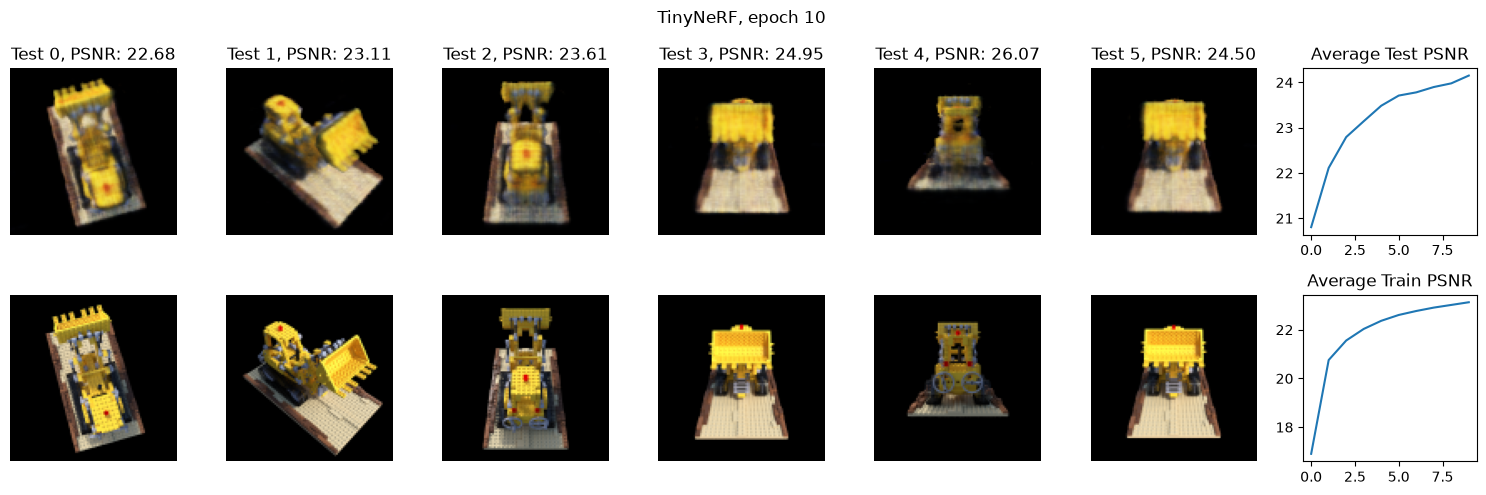

[TinyNeRF] epoch  11/100 | train PSNR  23.22 | test PSNR  24.11 |   9.7 s


[TinyNeRF] epoch  12/100 | train PSNR  23.28 | test PSNR  24.20 |   9.6 s


[TinyNeRF] epoch  13/100 | train PSNR  23.35 | test PSNR  24.43 |   9.6 s


[TinyNeRF] epoch  14/100 | train PSNR  23.44 | test PSNR  24.30 |   9.7 s


[TinyNeRF] epoch  15/100 | train PSNR  23.49 | test PSNR  24.42 |   9.7 s


[TinyNeRF] epoch  16/100 | train PSNR  23.53 | test PSNR  24.45 |   9.7 s


[TinyNeRF] epoch  17/100 | train PSNR  23.57 | test PSNR  24.56 |   9.7 s


[TinyNeRF] epoch  18/100 | train PSNR  23.59 | test PSNR  24.53 |   9.7 s


[TinyNeRF] epoch  19/100 | train PSNR  23.64 | test PSNR  24.63 |   9.7 s


[TinyNeRF] epoch  20/100 | train PSNR  23.68 | test PSNR  24.82 |   9.7 s


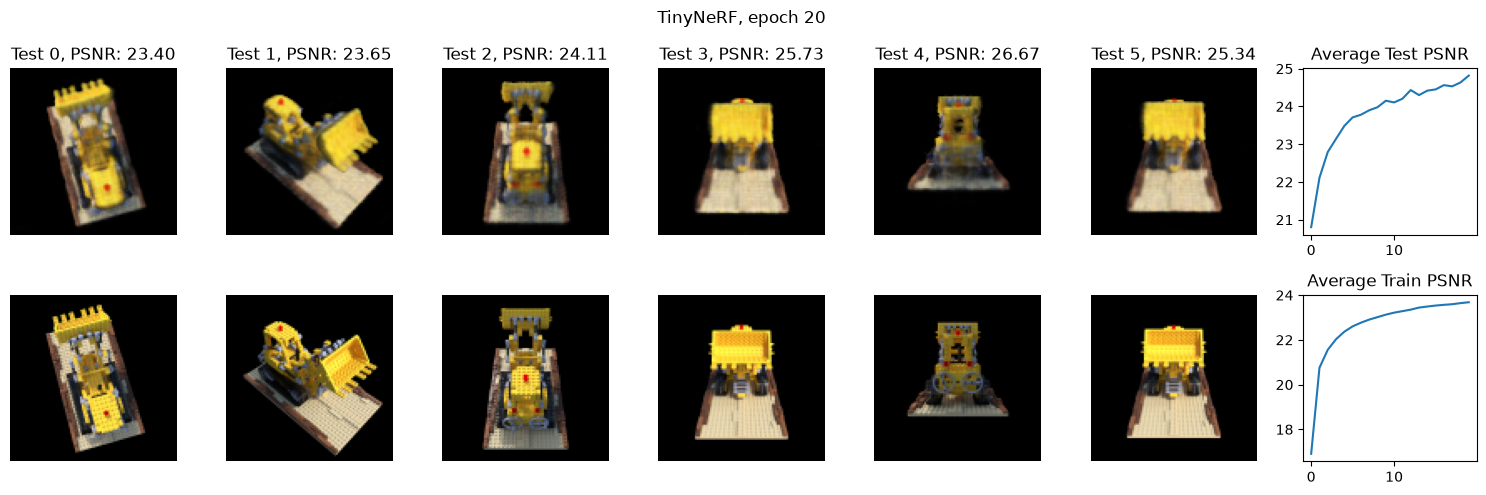

[TinyNeRF] epoch  21/100 | train PSNR  23.72 | test PSNR  24.76 |   9.7 s


[TinyNeRF] epoch  22/100 | train PSNR  23.76 | test PSNR  24.69 |   9.7 s


[TinyNeRF] epoch  23/100 | train PSNR  23.78 | test PSNR  24.76 |   9.7 s


[TinyNeRF] epoch  24/100 | train PSNR  23.82 | test PSNR  24.64 |   9.7 s


[TinyNeRF] epoch  25/100 | train PSNR  23.84 | test PSNR  24.72 |   9.7 s


[TinyNeRF] epoch  26/100 | train PSNR  23.85 | test PSNR  24.80 |   9.7 s


[TinyNeRF] epoch  27/100 | train PSNR  23.89 | test PSNR  24.84 |   9.7 s


[TinyNeRF] epoch  28/100 | train PSNR  23.90 | test PSNR  24.82 |  10.9 s


[TinyNeRF] epoch  29/100 | train PSNR  23.93 | test PSNR  24.89 |  14.8 s


[TinyNeRF] epoch  30/100 | train PSNR  23.94 | test PSNR  24.96 |  15.0 s


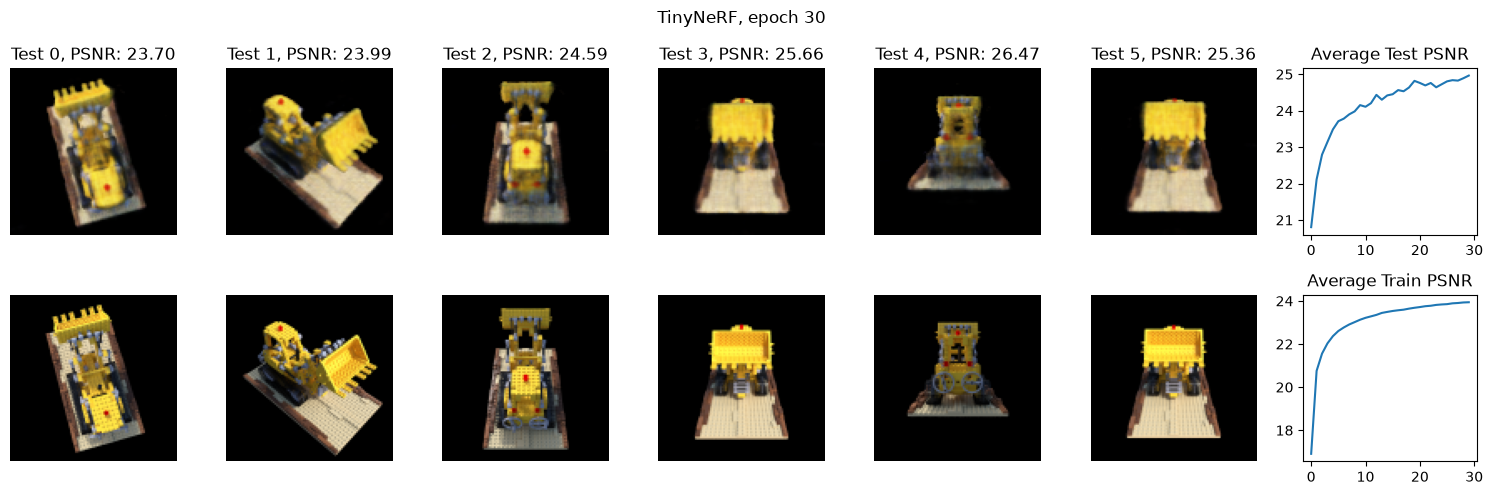

[TinyNeRF] epoch  31/100 | train PSNR  23.97 | test PSNR  24.87 |  14.7 s


[TinyNeRF] epoch  32/100 | train PSNR  23.99 | test PSNR  24.97 |  14.6 s


[TinyNeRF] epoch  33/100 | train PSNR  24.01 | test PSNR  24.97 |  14.8 s


[TinyNeRF] epoch  34/100 | train PSNR  24.02 | test PSNR  24.94 |  14.9 s


[TinyNeRF] epoch  35/100 | train PSNR  24.04 | test PSNR  24.97 |  14.9 s


[TinyNeRF] epoch  36/100 | train PSNR  24.06 | test PSNR  25.01 |  14.6 s


[TinyNeRF] epoch  37/100 | train PSNR  24.07 | test PSNR  25.03 |  14.7 s


[TinyNeRF] epoch  38/100 | train PSNR  24.10 | test PSNR  25.05 |  15.0 s


[TinyNeRF] epoch  39/100 | train PSNR  24.11 | test PSNR  25.09 |  15.0 s


[TinyNeRF] epoch  40/100 | train PSNR  24.11 | test PSNR  25.08 |  14.7 s


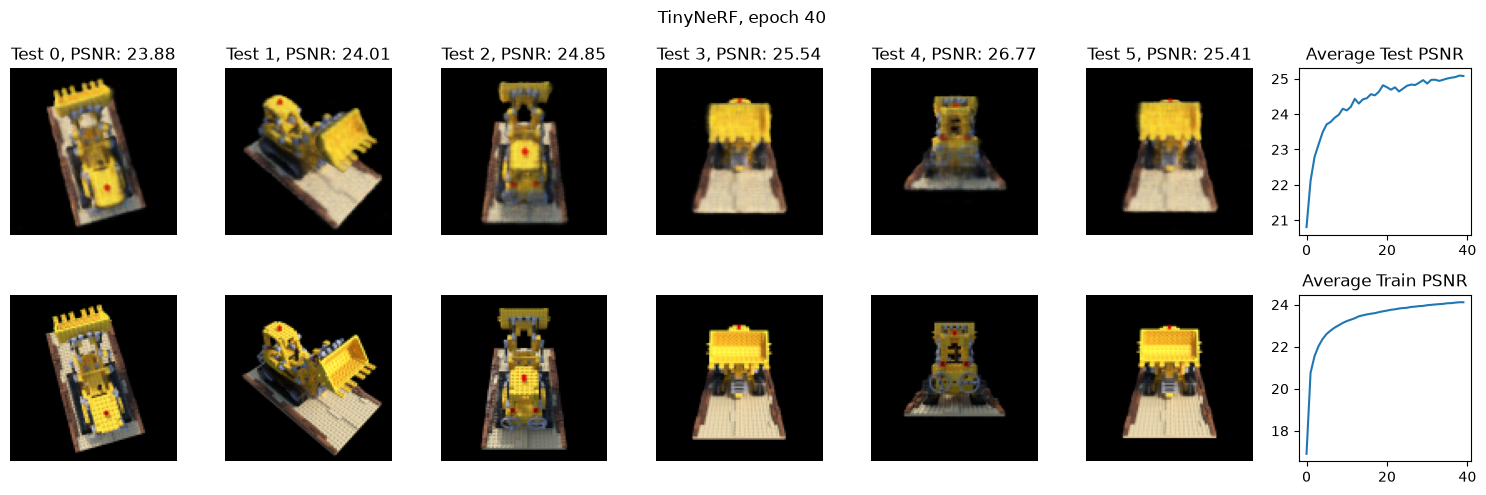

[TinyNeRF] epoch  41/100 | train PSNR  24.13 | test PSNR  25.01 |  14.5 s


[TinyNeRF] epoch  42/100 | train PSNR  24.14 | test PSNR  25.05 |  14.9 s


[TinyNeRF] epoch  43/100 | train PSNR  24.16 | test PSNR  25.02 |  14.9 s


[TinyNeRF] epoch  44/100 | train PSNR  24.17 | test PSNR  25.04 |  14.9 s


[TinyNeRF] epoch  45/100 | train PSNR  24.17 | test PSNR  25.18 |  14.6 s


[TinyNeRF] epoch  46/100 | train PSNR  24.18 | test PSNR  25.21 |  14.7 s


[TinyNeRF] epoch  47/100 | train PSNR  24.21 | test PSNR  25.11 |  14.9 s


[TinyNeRF] epoch  48/100 | train PSNR  24.20 | test PSNR  25.10 |  14.9 s


[TinyNeRF] epoch  49/100 | train PSNR  24.22 | test PSNR  25.14 |  15.0 s


[TinyNeRF] epoch  50/100 | train PSNR  24.23 | test PSNR  25.10 |  14.5 s


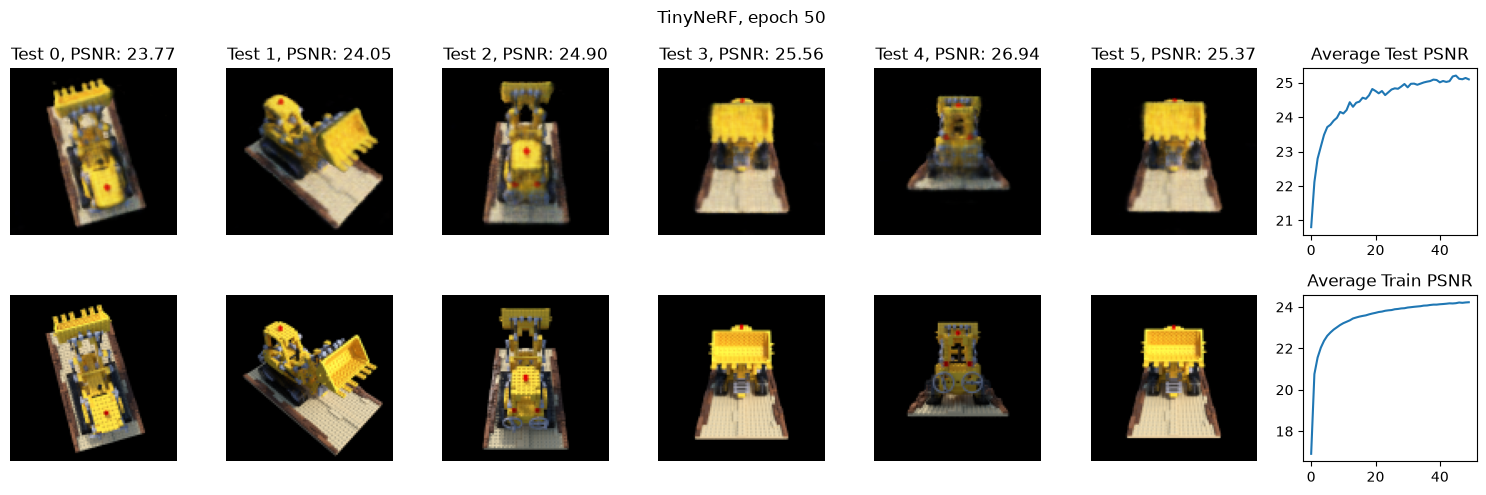

[TinyNeRF] epoch  51/100 | train PSNR  24.23 | test PSNR  25.19 |  14.8 s


[TinyNeRF] epoch  52/100 | train PSNR  24.24 | test PSNR  25.18 |  14.9 s


[TinyNeRF] epoch  53/100 | train PSNR  24.25 | test PSNR  25.14 |  14.9 s


[TinyNeRF] epoch  54/100 | train PSNR  24.28 | test PSNR  25.18 |  14.7 s


[TinyNeRF] epoch  55/100 | train PSNR  24.29 | test PSNR  25.24 |  14.7 s


[TinyNeRF] epoch  56/100 | train PSNR  24.31 | test PSNR  25.23 |  14.9 s


[TinyNeRF] epoch  57/100 | train PSNR  24.31 | test PSNR  25.31 |  15.0 s


[TinyNeRF] epoch  58/100 | train PSNR  24.31 | test PSNR  25.26 |  14.8 s


[TinyNeRF] epoch  59/100 | train PSNR  24.31 | test PSNR  25.23 |  14.5 s


[TinyNeRF] epoch  60/100 | train PSNR  24.33 | test PSNR  25.26 |  14.8 s


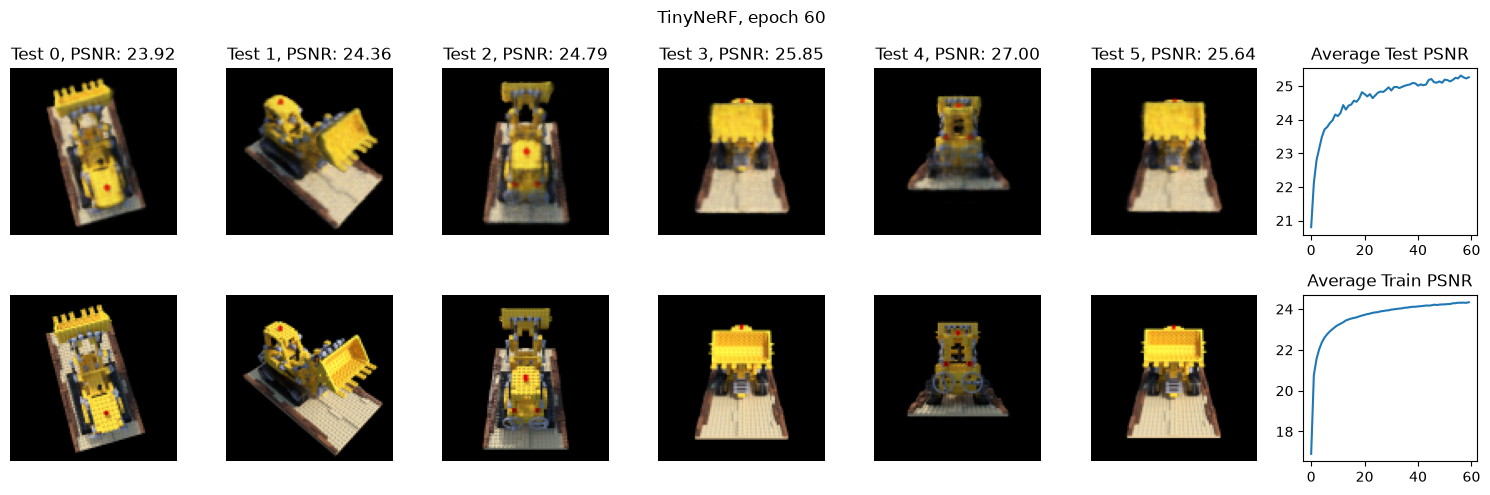

[TinyNeRF] epoch  61/100 | train PSNR  24.35 | test PSNR  25.26 |  13.5 s


[TinyNeRF] epoch  62/100 | train PSNR  24.34 | test PSNR  25.27 |  13.9 s


[TinyNeRF] epoch  63/100 | train PSNR  24.36 | test PSNR  25.34 |  14.7 s


[TinyNeRF] epoch  64/100 | train PSNR  24.36 | test PSNR  25.21 |  14.6 s


[TinyNeRF] epoch  65/100 | train PSNR  24.35 | test PSNR  25.31 |  14.8 s


[TinyNeRF] epoch  66/100 | train PSNR  24.37 | test PSNR  25.31 |  14.9 s


[TinyNeRF] epoch  67/100 | train PSNR  24.36 | test PSNR  25.30 |  14.8 s


[TinyNeRF] epoch  68/100 | train PSNR  24.38 | test PSNR  25.31 |  14.5 s


[TinyNeRF] epoch  69/100 | train PSNR  24.37 | test PSNR  25.34 |  14.7 s


[TinyNeRF] epoch  70/100 | train PSNR  24.37 | test PSNR  25.29 |  14.8 s


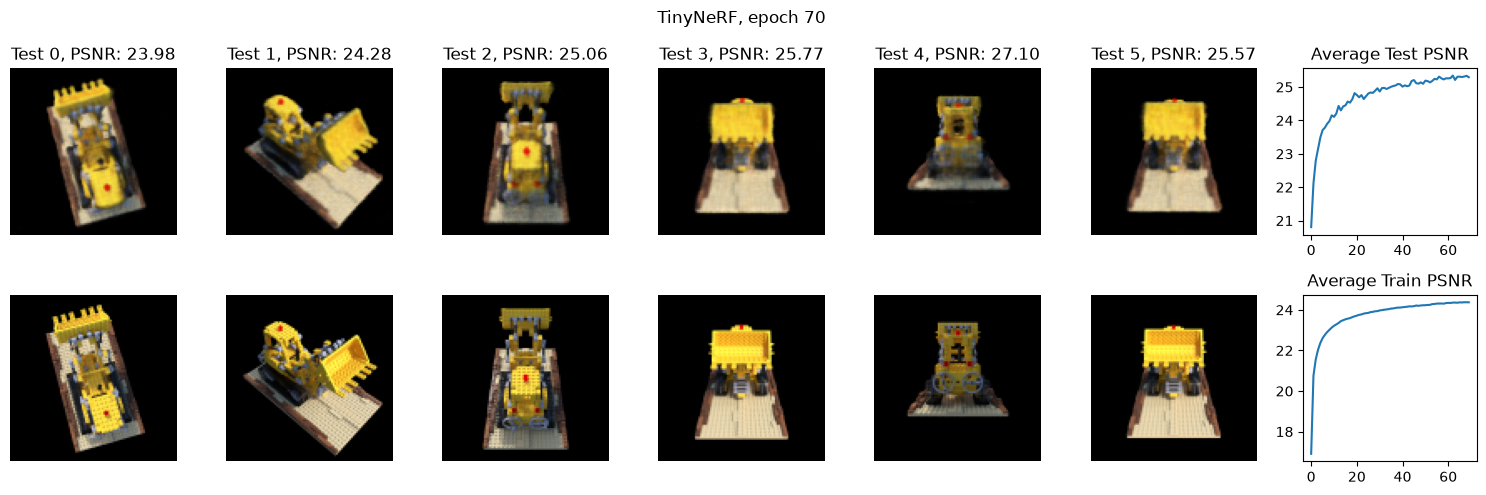

[TinyNeRF] epoch  71/100 | train PSNR  24.41 | test PSNR  25.34 |  14.8 s


[TinyNeRF] epoch  72/100 | train PSNR  24.40 | test PSNR  25.32 |  14.9 s


[TinyNeRF] epoch  73/100 | train PSNR  24.41 | test PSNR  25.39 |  14.5 s


[TinyNeRF] epoch  74/100 | train PSNR  24.40 | test PSNR  25.38 |  15.0 s


[TinyNeRF] epoch  75/100 | train PSNR  24.41 | test PSNR  25.36 |  14.9 s


[TinyNeRF] epoch  76/100 | train PSNR  24.41 | test PSNR  25.39 |  14.9 s


[TinyNeRF] epoch  77/100 | train PSNR  24.42 | test PSNR  25.32 |  14.7 s


[TinyNeRF] epoch  78/100 | train PSNR  24.41 | test PSNR  25.37 |  14.8 s


[TinyNeRF] epoch  79/100 | train PSNR  24.43 | test PSNR  25.34 |  14.8 s


[TinyNeRF] epoch  80/100 | train PSNR  24.43 | test PSNR  25.34 |  14.8 s


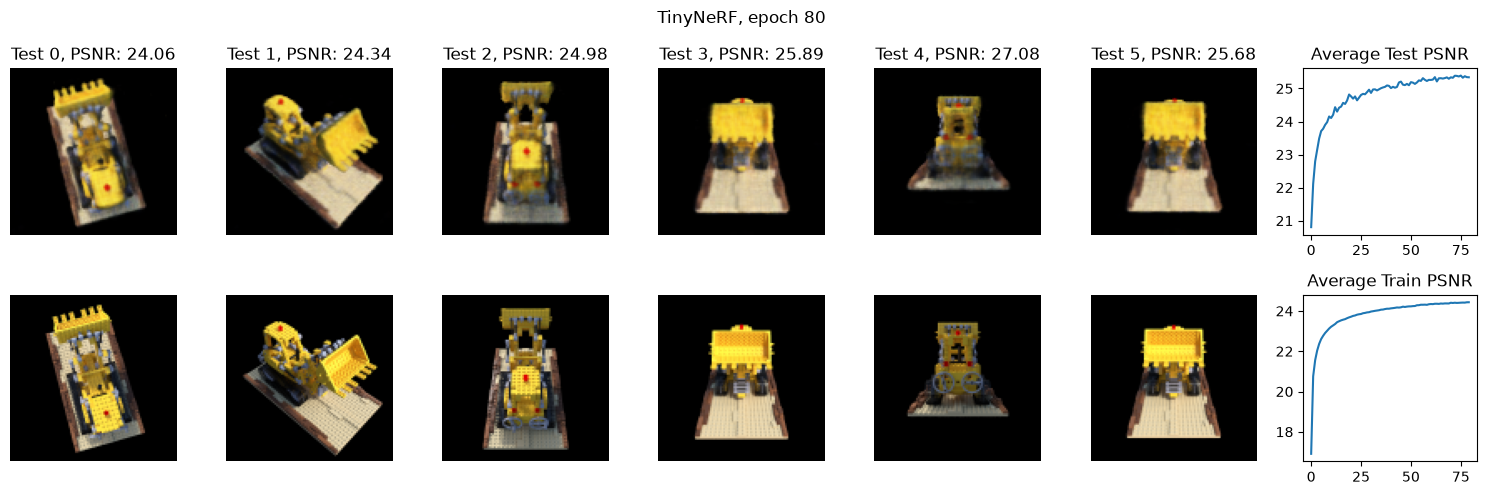

[TinyNeRF] epoch  81/100 | train PSNR  24.43 | test PSNR  25.35 |  14.8 s


[TinyNeRF] epoch  82/100 | train PSNR  24.44 | test PSNR  25.37 |  14.5 s


[TinyNeRF] epoch  83/100 | train PSNR  24.44 | test PSNR  25.32 |  14.8 s


[TinyNeRF] epoch  84/100 | train PSNR  24.43 | test PSNR  25.35 |  14.9 s


[TinyNeRF] epoch  85/100 | train PSNR  24.46 | test PSNR  25.42 |  15.0 s


[TinyNeRF] epoch  86/100 | train PSNR  24.45 | test PSNR  25.36 |  14.8 s


[TinyNeRF] epoch  87/100 | train PSNR  24.46 | test PSNR  25.31 |  14.4 s


[TinyNeRF] epoch  88/100 | train PSNR  24.47 | test PSNR  25.45 |  14.8 s


[TinyNeRF] epoch  89/100 | train PSNR  24.47 | test PSNR  25.41 |  14.9 s


[TinyNeRF] epoch  90/100 | train PSNR  24.45 | test PSNR  25.42 |  14.9 s


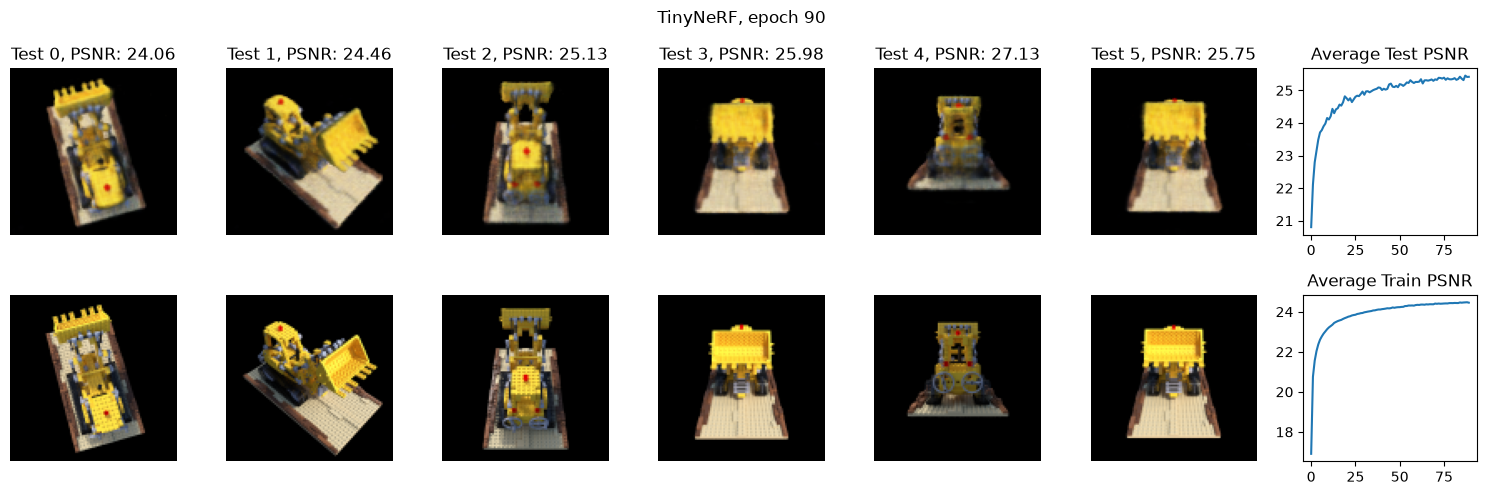

[TinyNeRF] epoch  91/100 | train PSNR  24.46 | test PSNR  25.41 |  14.7 s


[TinyNeRF] epoch  92/100 | train PSNR  24.46 | test PSNR  25.41 |  14.8 s


[TinyNeRF] epoch  93/100 | train PSNR  24.47 | test PSNR  25.40 |  14.8 s


[TinyNeRF] epoch  94/100 | train PSNR  24.46 | test PSNR  25.32 |  14.9 s


[TinyNeRF] epoch  95/100 | train PSNR  24.49 | test PSNR  25.37 |  12.7 s


[TinyNeRF] epoch  96/100 | train PSNR  24.48 | test PSNR  25.43 |  14.3 s


[TinyNeRF] epoch  97/100 | train PSNR  24.48 | test PSNR  25.38 |  15.0 s


[TinyNeRF] epoch  98/100 | train PSNR  24.49 | test PSNR  25.37 |  14.9 s


[TinyNeRF] epoch  99/100 | train PSNR  24.48 | test PSNR  25.35 |  14.9 s


[TinyNeRF] epoch 100/100 | train PSNR  24.49 | test PSNR  25.41 |  14.7 s


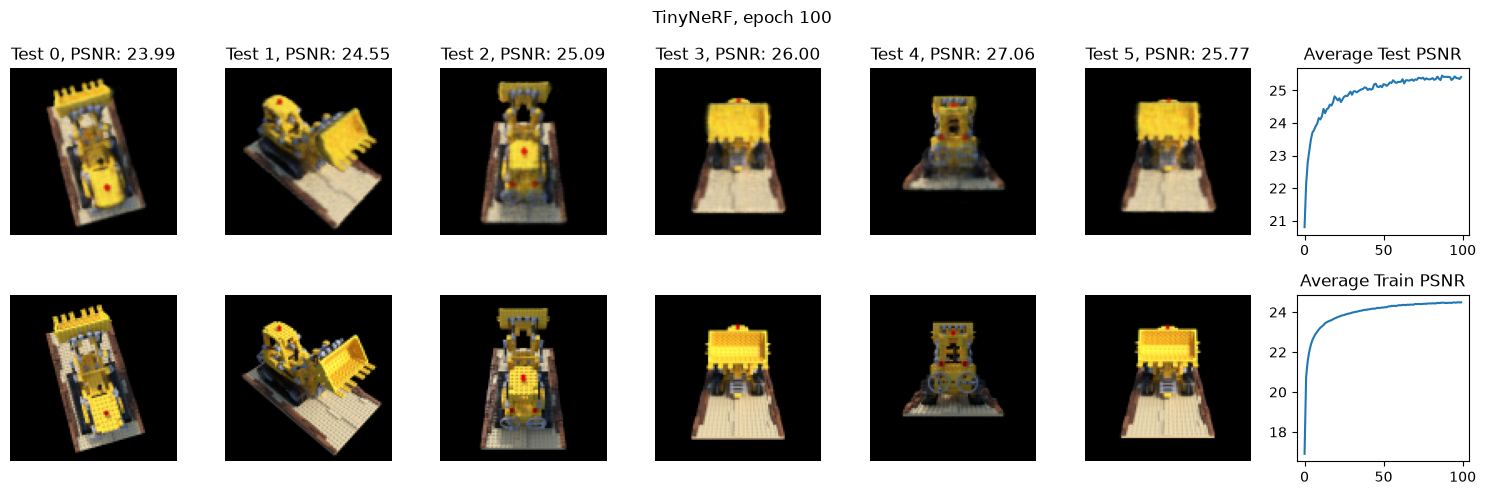

TinyNeRF final test PSNR: 25.41 dB | mean epoch time 13.3 s


In [13]:
# Initialize model (Tutorial 10.4 architecture) and train it with the shared loop
model = TinyNeRF(filter_size=128, L_embed=6).to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

# Training renders jittered (stratified) samples; testing renders the deterministic grid.
render_train = lambda rays_o, rays_d: [render_rays_tiny(model, rays_o, rays_d, NEAR, FAR, N_SAMPLES_TINY, rand=True)]
render_test = lambda rays_o, rays_d: render_rays_tiny(model, rays_o, rays_d, NEAR, FAR, N_SAMPLES_TINY, rand=False)

history = train("TinyNeRF", [model], render_train, render_test, N_EPOCHS)
print(f"TinyNeRF final test PSNR: {history['test_psnr'][-1]:.2f} dB | "
      f"mean epoch time {np.mean(history['epoch_seconds']):.1f} s")

Save the trained weights and this model's per-epoch history for `main_report.ipynb`, which reloads
them instead of training again.

In [14]:
# Save the trained weights and the training history for main_report.ipynb
torch.save({"model": model.state_dict(),
            "config": {"filter_size": 128, "L_embed": 6, "num_samples": N_SAMPLES_TINY,
                       "epochs": N_EPOCHS, "seed": SEED}}, "tinynerf.pth")
save_history("TinyNeRF", history)
print("saved tinynerf.pth and training_history.json")

saved tinynerf.pth and training_history.json


## Interactive Visualization: Novel View Synthesis

In [15]:
# Interactive novel-view synthesis (Tutorial 10.4). The camera sits on a sphere around the object;
# theta = azimuth, phi = elevation, radius = distance.
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about x-axis (phi)
rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi),  torch.cos(phi), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about y-axis (theta)
rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0,  torch.cos(th), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(torch.tensor(phi / 180. * np.pi)) @ c2w
    c2w = rot_theta(torch.tensor(theta / 180. * np.pi)) @ c2w
    c2w = torch.tensor([
        [-1, 0, 0, 0],
        [ 0, 0, 1, 0],
        [ 0, 1, 0, 0],
        [ 0, 0, 0, 1],
    ], dtype=torch.float32) @ c2w
    return c2w.to(device)

The tutorial's interactive viewer: sliders move the camera over a sphere around the object, which
needs a live kernel with `ipywidgets` (a stored notebook shows a placeholder instead).

In [16]:
# Interactive viewer (needs ipywidgets in a live kernel); falls back to one static render.
render_novel = lambda rays_o, rays_d: render_rays_tiny(model, rays_o, rays_d, NEAR, FAR, N_SAMPLES_TINY)

def f(**kwargs):
    img = render_image(render_novel, pose_spherical(**kwargs)).clamp(0, 1).cpu().numpy()
    plt.figure(2, figsize=(20, 6)); plt.imshow(img); plt.axis('off'); plt.show()

try:
    from ipywidgets import interactive, widgets
    sldr = lambda v, mi, ma: widgets.FloatSlider(value=v, min=mi, max=ma, step=0.01)
    names = [['theta', [100., 0., 360.]], ['phi', [-30., -90., 0.]], ['radius', [4., 3., 5.]]]
    interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
    interactive_plot.children[-1].layout.height = '350px'
    display(interactive_plot)
except ImportError:
    f(theta=100., phi=-30., radius=4.)

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…